In [1]:
!pip install yfinance

# **Import Libraries**

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU, Dropout

**DOWNLOAD DATA**

In [3]:
df = yf.download("AAPL", start="2018-01-01", end="2025-01-01")

df.head()

/tmp/ipykernel_14027/602099449.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", start="2018-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2018-01-02,40.304173,40.313533,39.602254,39.812832,102223600
2018-01-03,40.297146,40.839965,40.233976,40.367338,118071600
2018-01-04,40.484341,40.587289,40.262067,40.369693,89738400
2018-01-05,40.945255,41.031824,40.489009,40.580258,94640000
2018-01-08,40.793179,41.087983,40.694907,40.793179,82271200


**CHECK DATA**

In [4]:
print(df.shape)
df.tail()

(1761, 5)


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2024-12-24,256.797211,256.807136,253.903002,254.101927,23234700
2024-12-26,257.612701,258.686851,256.230269,256.787224,27237100
2024-12-27,254.201370,257.294489,251.685117,256.429191,42355300
2024-12-30,250.829788,252.122728,249.387669,250.859624,35557500
2024-12-31,249.059448,251.903910,248.074822,251.068478,39480700


**VISUALIZE STOCK PRICE**

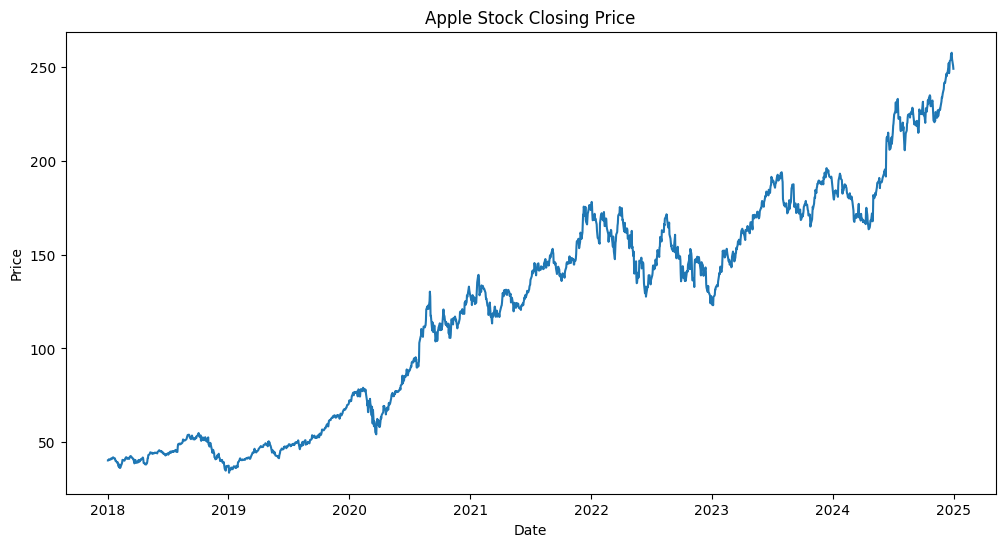

In [5]:
plt.figure(figsize=(12,6))
plt.plot(df['Close'])
plt.title("Apple Stock Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

**PREPROCESSING**

In [6]:
data = df[['Close']]

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(data)

**CREATE SEQUENCES**

In [7]:
X = []
y = []

sequence_length = 60

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i])
    y.append(scaled_data[i])

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(1701, 60, 1)
(1701, 1)


**TRAIN TEST SPLIT**

In [8]:
split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

print(X_train.shape)
print(X_test.shape)

(1360, 60, 1)
(341, 60, 1)


# **BUILD SIMPLE RNN MODEL**

In [9]:
rnn_model = Sequential()

rnn_model.add(SimpleRNN(50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
rnn_model.add(Dropout(0.2))

rnn_model.add(SimpleRNN(50))
rnn_model.add(Dropout(0.2))

rnn_model.add(Dense(1))

rnn_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 60, 50)         │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,701 (30.08 KB)

 Trainable params: 7,701 (30.08 KB)

 Non-trainable params: 0 (0.00 B)

# **TRAIN RNN MODEL**

In [10]:
rnn_history = rnn_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - loss: 0.1087 - val_loss: 0.0089
Epoch 2/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0281 - val_loss: 0.0092
Epoch 3/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0169 - val_loss: 0.0090
Epoch 4/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0131 - val_loss: 0.0145
Epoch 5/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0089 - val_loss: 0.0036
Epoch 6/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0077 - val_loss: 0.0058
Epoch 7/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 0.0066 - val_loss: 0.0020
Epoch 8/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0055 - val_loss: 0.0028
Epoch 9/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0054 - val_loss: 0.0037
Epoch 10/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0045 - val_loss: 0.0018
Epoch 11/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0046 - val_loss: 0.0024
Epoch 12/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0

**RNN PREDICTIONS**

In [11]:
rnn_predictions = rnn_model.predict(X_test)

rnn_predictions = scaler.inverse_transform(rnn_predictions)
y_test_actual = scaler.inverse_transform(y_test)

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step


**RNN EVALUATION**

In [12]:
rnn_rmse = np.sqrt(mean_squared_error(y_test_actual, rnn_predictions))

print("RNN RMSE:", rnn_rmse)

RNN RMSE: 11.176755987877062


# RNN GRAPH

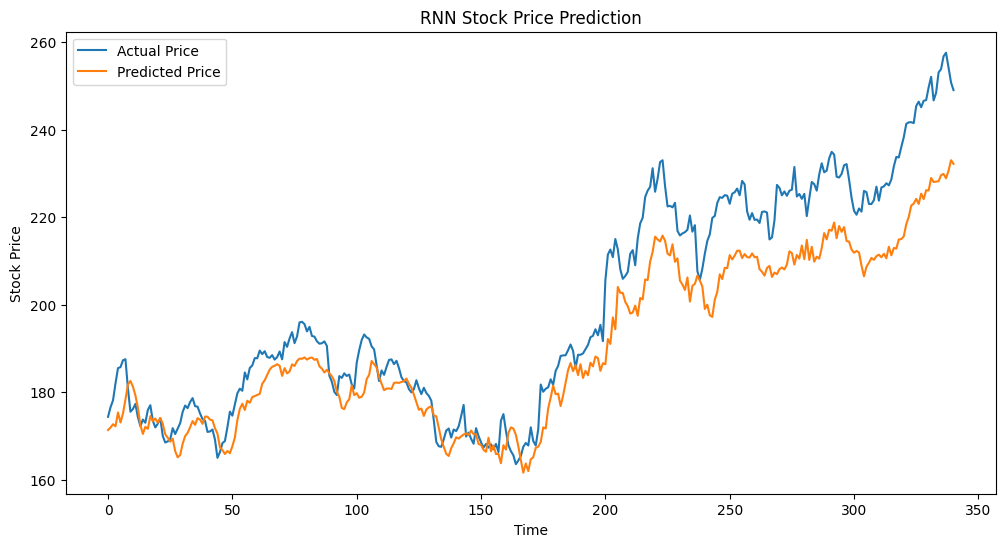

In [13]:
plt.figure(figsize=(12,6))

plt.plot(y_test_actual, label='Actual Price')
plt.plot(rnn_predictions, label='Predicted Price')

plt.title("RNN Stock Price Prediction")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()

plt.show()

## **BUILD LSTM MODEL**

In [14]:
lstm_model = Sequential()

lstm_model.add(LSTM(
    50,
    return_sequences=True,
    input_shape=(X_train.shape[1], 1)
))
lstm_model.add(Dropout(0.2))

lstm_model.add(LSTM(50))
lstm_model.add(Dropout(0.2))

lstm_model.add(Dense(1))

lstm_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

**TRAIN LSTM MODEL**

In [15]:
lstm_history = lstm_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - loss: 0.0202 - val_loss: 0.0087
Epoch 2/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - loss: 0.0023 - val_loss: 0.0013
Epoch 3/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - loss: 0.0020 - val_loss: 0.0025
Epoch 4/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 0.0017 - val_loss: 9.1918e-04
Epoch 5/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - loss: 0.0016 - val_loss: 0.0023
Epoch 6/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 0.0016 - val_loss: 7.9274e-04
Epoch 7/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - loss: 0.0015 - val_loss: 0.0018
Epoch 8/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 7s 114ms/step - loss: 0.0015 - val_loss: 0.0015
Epoch 9/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - loss: 0.0014 - val_loss: 8.5717e-04
Epoch 10/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0014 - val_loss: 0.0033
Epoch 11/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - loss: 0.0014 - val_loss: 8.1332e-04
Epoch 12/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms

**LSTM PREDICTIONS**

In [16]:
lstm_predictions = lstm_model.predict(X_test)

lstm_predictions = scaler.inverse_transform(lstm_predictions)

11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 103ms/step


**LSTM EVALUATION**

In [17]:
lstm_rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        lstm_predictions
    )
)

print("LSTM RMSE:", lstm_rmse)

LSTM RMSE: 6.596558895258422


**LSTM GRAPH**

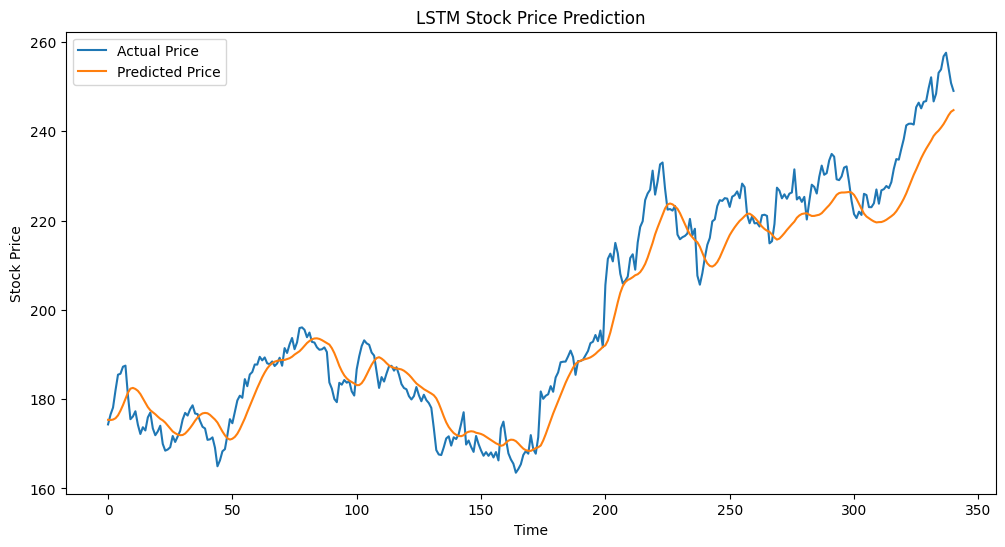

In [18]:
plt.figure(figsize=(12,6))

plt.plot(y_test_actual, label='Actual Price')
plt.plot(lstm_predictions, label='Predicted Price')

plt.title("LSTM Stock Price Prediction")
plt.xlabel("Time")
plt.ylabel("Stock Price")

plt.legend()

plt.show()

# **BUILD GRU MODEL**

In [19]:
gru_model = Sequential()

gru_model.add(GRU(
    50,
    return_sequences=True,
    input_shape=(X_train.shape[1], 1)
))
gru_model.add(Dropout(0.2))

gru_model.add(GRU(50))
gru_model.add(Dropout(0.2))

gru_model.add(Dense(1))

gru_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

gru_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 60, 50)         │         7,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 50)             │        15,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,301 (91.02 KB)

 Trainable params: 23,301 (91.02 KB)

 Non-trainable params: 0 (0.00 B)

**TRAIN GRU MODEL**

In [20]:
gru_history = gru_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 10s 116ms/step - loss: 0.0166 - val_loss: 0.0012
Epoch 2/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - loss: 0.0021 - val_loss: 9.0888e-04
Epoch 3/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - loss: 0.0018 - val_loss: 5.7044e-04
Epoch 4/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 117ms/step - loss: 0.0017 - val_loss: 4.1879e-04
Epoch 5/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 97ms/step - loss: 0.0015 - val_loss: 4.1046e-04
Epoch 6/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - loss: 0.0014 - val_loss: 4.3999e-04
Epoch 7/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 129ms/step - loss: 0.0014 - val_loss: 4.6459e-04
Epoch 8/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - loss: 0.0014 - val_loss: 5.0566e-04
Epoch 9/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 8s 179ms/step - loss: 0.0014 - val_loss: 4.3375e-04
Epoch 10/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - loss: 0.0013 - val_loss: 6.1383e-04
Epoch 11/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step - loss: 0.0012 - val_loss: 5.2785e-04
Epoch 12/20
43/43 

**GRU PREDICTIONS**

In [21]:
gru_predictions = gru_model.predict(X_test)

gru_predictions = scaler.inverse_transform(gru_predictions)

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step


**GRU EVALUATION**

In [22]:
gru_rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        gru_predictions
    )
)

print("GRU RMSE:", gru_rmse)

GRU RMSE: 5.359597910553117


**GRU GRAPH**

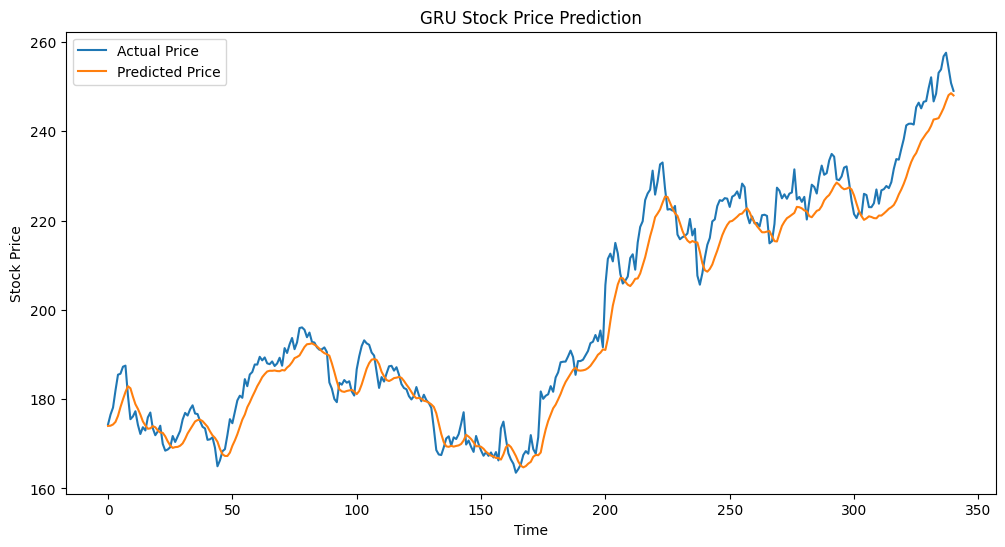

In [23]:
plt.figure(figsize=(12,6))

plt.plot(y_test_actual, label='Actual Price')
plt.plot(gru_predictions, label='Predicted Price')

plt.title("GRU Stock Price Prediction")
plt.xlabel("Time")
plt.ylabel("Stock Price")

plt.legend()

plt.show()

**MODEL COMPARISON TABLE**

In [24]:
comparison = pd.DataFrame({
    "Model": ["RNN", "LSTM", "GRU"],
    "RMSE": [rnn_rmse, lstm_rmse, gru_rmse]
})

comparison

,Model,RMSE
0,RNN,11.176756
1,LSTM,6.596559
2,GRU,5.359598


**COMPARISON GRAPH**

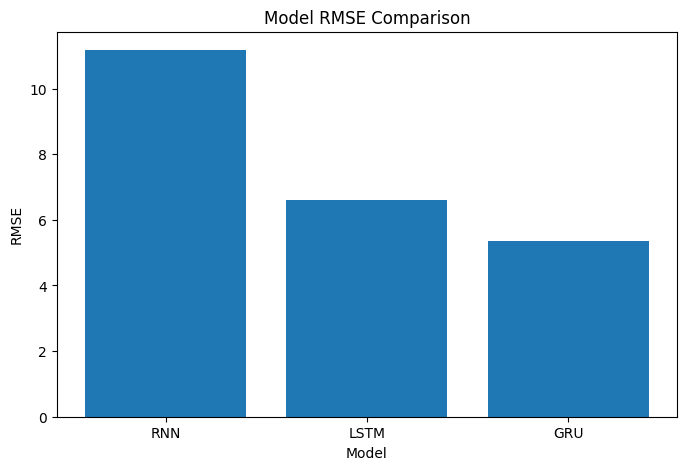

In [25]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["RMSE"]
)

plt.title("Model RMSE Comparison")
plt.xlabel("Model")
plt.ylabel("RMSE")

plt.show()

**SAVE BEST MODEL**

In [26]:
gru_model.save("gru_stock_prediction_model.h5")